In [3]:
pip install pandas scikit-learn


Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd

In [5]:
pd.read_csv("D:\Data Analytics\heart.csv")

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [6]:
df = pd.read_csv("D:\Data Analytics\heart.csv")

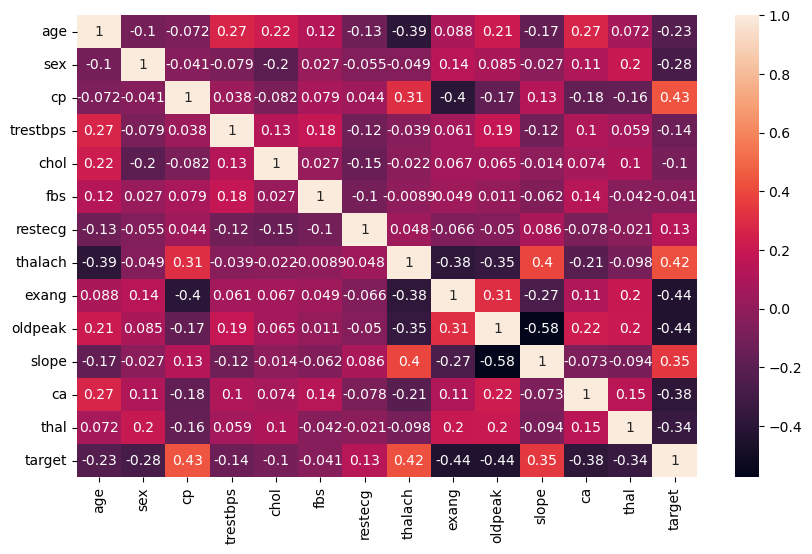

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True)
plt.show()

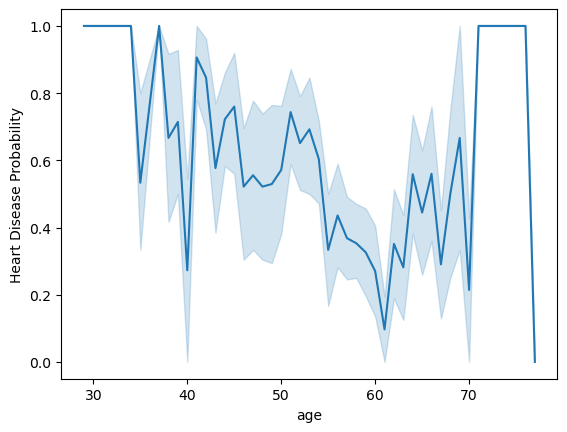

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.lineplot(x='age', y='target', data=df)
plt.ylabel("Heart Disease Probability")
plt.show()

In [9]:
df["age"].max()

77

In [10]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=100)

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
x = df.drop("target", axis=1)
y = df["target"]

In [13]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

In [14]:
model.fit(x_train, y_train) 

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [15]:
y_predict = model.predict(x_test)
print(y_predict)

[1 1 0 1 0 0 0 1 0 1 0 1 1 0 1 0 1 1 0 0 0 1 0 0 0 0 0 1 1 0 0 0 1 0 1 0 1
 0 1 1 0 1 0 1 0 1 0 1 1 0 0 1 1 1 0 0 1 0 1 1 0 0 1 0 0 0 0 0 0 0 1 0 0 1
 0 0 1 0 0 0 0 0 0 1 0 1 0 0 0 1 0 0 1 0 1 0 1 1 1 1 1 1 0 0 0 1 1 0 1 0 0
 0 0 1 1 1 1 0 1 1 0 0 1 0 0 0 1 1 1 0 1 0 0 1 0 1 0 1 1 0 1 0 1 0 0 1 0 0
 1 0 0 1 0 1 0 0 1 1 0 1 0 0 0 0 1 1 0 1 0 1 0 1 0 1 1 0 0 0 0 1 0 1 0 1 1
 0 1 0 0 0 1 0 1 0 1 1 0 1 1 0 1 0 1 0 1]


In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, y_predict)
mse = mean_squared_error(y_test, y_predict)

In [17]:
print(f"MAE: {mae}")
print(f"MSE: {mse}")

MAE: 0.0
MSE: 0.0


In [18]:
df.head(11)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
5,58,0,0,100,248,0,0,122,0,1.0,1,0,2,1
6,58,1,0,114,318,0,2,140,0,4.4,0,3,1,0
7,55,1,0,160,289,0,0,145,1,0.8,1,1,3,0
8,46,1,0,120,249,0,0,144,0,0.8,2,0,3,0
9,54,1,0,122,286,0,0,116,1,3.2,1,2,2,0


In [19]:
print(len(df))


1025


In [20]:
me = [[19, 1, 0, 115, 170, 0, 0, 300, 0, 0.0, 2, 0, 2]]
me_df = pd.DataFrame(me, columns=x.columns)

probability = model.predict_proba(me_df)
print(f"Your chance to heart attack: {probability[0][1]}")


Your chance to heart attack: 0.82


In [37]:
print(df.head(1))


   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   

   ca  thal  target  
0   2     3       0  


In [50]:

import joblib
import ipywidgets as widgets
from IPython.display import display, clear_output
import warnings
warnings.filterwarnings("ignore")

# ---------------- Inputs ----------------
age = widgets.IntSlider(description="Age", min=1, max=120, value=50)
sex = widgets.Dropdown(description="Sex", options=[0,1])
cp = widgets.Dropdown(description="Chest Pain", options=[0,1,2,3])
trestbps = widgets.IntSlider(description="BP", min=80, max=200, value=120)
chol = widgets.IntSlider(description="Chol", min=100, max=600, value=200)
fbs = widgets.Dropdown(description="FBS", options=[0,1])
restecg = widgets.Dropdown(description="ECG", options=[0,1,2])
thalach = widgets.IntSlider(description="Max HR", min=50, max=250, value=150)
exang = widgets.Dropdown(description="Exang", options=[0,1])
oldpeak = widgets.FloatSlider(description="Oldpeak", min=0.0, max=6.0, value=1.0)
slope = widgets.Dropdown(description="Slope", options=[0,1,2])
ca = widgets.Dropdown(description="CA", options=[0,1,2,3])
thal = widgets.Dropdown(description="Thal", options=[0,1,2,3])

button = widgets.Button(description="Predict Risk")
output = widgets.Output()

# Display UI
display(
    age, sex, cp, trestbps, chol, fbs, restecg,
    thalach, exang, oldpeak, slope, ca, thal,
    button, output
)

# ---------------- Logic ----------------
def predict(b):
    with output:
        clear_output()

        data = [[
            age.value, sex.value, cp.value, trestbps.value, chol.value,
            fbs.value, restecg.value, thalach.value, exang.value,
            oldpeak.value, slope.value, ca.value, thal.value
        ]]

        prob = model.predict_proba(data)[0][1]

        print("Risk Probability:", prob)

button.on_click(predict)

IntSlider(value=50, description='Age', max=120, min=1)

Dropdown(description='Sex', options=(0, 1), value=0)

Dropdown(description='Chest Pain', options=(0, 1, 2, 3), value=0)

IntSlider(value=120, description='BP', max=200, min=80)

IntSlider(value=200, description='Chol', max=600, min=100)

...

Dropdown(description='Slope', options=(0, 1, 2), value=0)

Dropdown(description='CA', options=(0, 1, 2, 3), value=0)

Dropdown(description='Thal', options=(0, 1, 2, 3), value=0)

Button(description='Predict Risk', style=ButtonStyle())

Output()